[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giuliofranzese/Cajal/blob/main/soi/notebook_soi_vbn.ipynb)

# SOI on VBN dataset

This notebook downloads vbn.pth, instantiates datasets for each time bin and change/non_change (10 datasets), trains SB_joint (SOI) for each dataset and computes o-information, then plots results.


In [1]:
import sys
import os
import shutil
from pathlib import Path
print('Python', sys.version)

# Robustly locate soi_repo or clone if missing
cwd = Path.cwd()
REPO_GIT_URL = 'https://github.com/MustaphaBounoua/soi.git'
soi_repo_dir_candidate = cwd / 'soi_repo' # Explicitly assume soi_repo is directly in cwd

soi_repo_dir = None

# Check if the assumed soi_repo_dir exists and is valid
if soi_repo_dir_candidate.is_dir() and (soi_repo_dir_candidate / 'src').is_dir():
    soi_repo_dir = soi_repo_dir_candidate
else:
    # Fallback to general search in parent directories if not found directly in cwd
    for p in [cwd] + list(cwd.parents)[:5]:
        cand = p / 'soi_repo'
        if cand.is_dir() and (cand / 'src').is_dir():
            soi_repo_dir = cand
            break
        cand2 = p / 'soi' / 'soi_repo'
        if cand2.is_dir() and (cand2 / 'src').is_dir():
            soi_repo_dir = cand2
            break

if soi_repo_dir is None:
    print(f'soi_repo not found; cloning into {cwd / 'soi_repo'}')
    if shutil.which('git') is None:
        raise RuntimeError('git is required to clone soi_repo; please install git and re-run the notebook')
    import subprocess
    dest = cwd / 'soi_repo'
    dest.parent.mkdir(parents=True, exist_ok=True)
    subprocess.check_call(['git', 'clone', '--depth', '1', REPO_GIT_URL, str(dest)])
    soi_repo_dir = dest
elif soi_repo_dir.is_dir(): # Check if it's an existing directory and pull latest changes
    print(f'soi_repo found at {soi_repo_dir}; pulling latest changes...')
    if shutil.which('git') is None:
        raise RuntimeError('git is required to pull soi_repo; please install git and re-run the notebook')
    import subprocess
    try:
        subprocess.check_call(['git', '-C', str(soi_repo_dir), 'pull'])
        print('Successfully pulled latest changes for soi_repo.')
    except subprocess.CalledProcessError as e:
        print(f'Error pulling soi_repo: {e}. Attempting to re-clone...')
        # If pull fails, e.g., due to detached HEAD or local changes, try re-cloning
        if soi_repo_dir.exists():
            shutil.rmtree(soi_repo_dir)
        dest = cwd / 'soi_repo'
        dest.parent.mkdir(parents=True, exist_ok=True)
        subprocess.check_call(['git', 'clone', '--depth', '1', REPO_GIT_URL, str(dest)])
        soi_repo_dir = dest
        print('Successfully re-cloned soi_repo.')

repo_root = str(soi_repo_dir)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
    print('Added repo_root to sys.path', repo_root)
os.makedirs('results/soi_vbn', exist_ok=True)
vbn_pth = os.path.join(str(cwd), 'vbn.pth')

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
soi_repo not found; cloning into /content/soi_repo
Added repo_root to sys.path /content/soi_repo


In [2]:
import os
import urllib.request
from pathlib import Path

cwd = Path.cwd()
vbn_pth = str(cwd / 'vbn_5.pth')

if not os.path.exists(vbn_pth):
    print('Downloading vbn_5.pth from HF bucket...')
    url = "https://huggingface.co/buckets/mustabou/mybucket/resolve/vbn_5.pth?download=true"
    urllib.request.urlretrieve(url, vbn_pth)
    print('Downloaded to', vbn_pth)
else:
    print('vbn_5.pth already exists at', vbn_pth)

# --- Fix for FileNotFoundError: 'data/good_sessions.pickle' ---
# Ensure 'data' directory exists
data_dir = cwd / 'data'
os.makedirs(data_dir, exist_ok=True)

good_sessions_pth = str(data_dir / 'good_sessions.pickle')

if not os.path.exists(good_sessions_pth):
    print('Downloading good_sessions.pickle from HF bucket...')
    # Assuming the good_sessions.pickle is also in the same bucket
    url_good_sessions = "https://huggingface.co/buckets/mustabou/mybucket/resolve/good_sessions.pickle?download=true"
    urllib.request.urlretrieve(url_good_sessions, good_sessions_pth)
    print('Downloaded to', good_sessions_pth)
else:
    print('good_sessions.pickle already exists at', good_sessions_pth)
# -------------------------------------------------------------


from soi_repo.src.vbn.vbn import VBNDataset
import torch
torch.serialization.add_safe_globals([VBNDataset])
vbn_bins_5 = torch.load(vbn_pth, map_location='cpu')
print('Loaded. Keys:', sorted(vbn_bins_5.keys()))

Downloaded to /content/vbn_5.pth
Downloaded to /content/data/good_sessions.pickle
Loaded. Keys: ['0', '1', '2', '3', '4']


In [3]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 69.3 MB/s eta 0:00:00


In [4]:
import os
import io
import urllib.request
import torch
from torch.utils.data import DataLoader
from soi_repo.src.libs.soi import SOI
from soi_repo.experiments.config import get_config
import numpy as np


parser = get_config()
args = parser.parse_args([])
args.dim = 5
args.max_epochs = 10
args.mc_iter = 3
args.arch = "mlp"
args.accelerator = "gpu"


# ── config ─────────────────────────────────────────────────────
MODE       = "infer"    # "train" → train  |  "infer" → download + load
HF_USER    = "mustabou"
BUCKET     = "mybucket"
BASE_URL   = f"https://huggingface.co/buckets/{HF_USER}/{BUCKET}/resolve"
MODELS_DIR = "./models"
os.makedirs(MODELS_DIR, exist_ok=True)
# ───────────────────────────────────────────────────────────────


def model_local_path(time, change):
    return os.path.join(MODELS_DIR, f"soi_{change}_bin{time}.pt")

def model_url(time, change):
    return f"{BASE_URL}/soi_{change}_bin{time}.pt?download=true"

def download_model(time, change):
    dest = model_local_path(time, change)
    if os.path.exists(dest):
        return  # already cached
    url = model_url(time, change)
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, dest)


def get_samples(test_loader, device, N=10000):
    var_list = list(test_loader.dataset[0].keys())
    data = {var: torch.Tensor().to(device) for var in var_list}
    for batch in test_loader:
        for var in var_list:
            data[var] = torch.cat([data[var], batch[var].to(device)])
    return {var: data[var][:N, :] for var in var_list}


structure = ["VISp", "VISl", "VISal", "VISrl", "VISam", "VISpm"]
results   = {"change": {}, "non_change": {}}


for time in range(0, 5):
    for change in ["change", "non_change"]:

        train_set   = vbn_bins_5[str(time)][change]
        data_loader = DataLoader(train_set, batch_size=args.bs, shuffle=True,
                                 num_workers=8, drop_last=True)
        device = "cuda" if (args.accelerator == "gpu" and torch.cuda.is_available()) else "cpu"

        model = SOI(args, nb_var=6, var_list={i: args.dim for i in structure})

        if MODE == "train":
            print(f"[train] bin={time}  {change}")
            model.fit(data_loader, None)
            torch.save(model.state_dict(), model_local_path(time, change))

        elif MODE == "infer":
            print(f"[infer] loading bin={time}  {change}")
            download_model(time, change)
            model.load_state_dict(
                torch.load(model_local_path(time, change), map_location=device)
            )

        test_samples = get_samples(data_loader, device=device, N=2000)
        r   = {"e": model.compute_o_inf(test_samples)}
        r_s = {"o_inf": [], "s_inf": [], "tc": [], "dtc": []}
        model.to(device)
        model.eval()
        for sess in train_set.get_sessions():
            out = model.compute_o_inf(sess)
            for k in r_s:
                r_s[k].append(out[k])
        r["ses"] = r_s

        results[change][time] = r
        print("O_inf", np.mean(r_s["o_inf"]))

/content/soi_repo/src/libs/info_measures.py:56: SyntaxWarning: invalid escape sequence '\O'
  S $\Omega $ I: Score-based O-INFORMATION Estimation. arXiv preprint arXiv:2402.05667.
/content/soi_repo/src/libs/info_measures.py:88: SyntaxWarning: invalid escape sequence '\O'
  S $\Omega $ I: Score-based O-INFORMATION Estimation. arXiv preprint arXiv:2402.05667.
/content/soi_repo/src/libs/info_measures.py:131: SyntaxWarning: invalid escape sequence '\O'
  S $\Omega $ I: Score-based O-INFORMATION Estimation. arXiv preprint arXiv:2402.05667.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_n

[infer] loading bin=0  change


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


O_inf 34.08996735678779
[infer] loading bin=0  non_change
O_inf 32.54090166533435
[infer] loading bin=1  change
O_inf 31.859778651484742
[infer] loading bin=1  non_change
O_inf 37.808889709137105
[infer] loading bin=2  change
O_inf 32.162621522391284
[infer] loading bin=2  non_change
O_inf 29.491094198491837
[infer] loading bin=3  change
O_inf 33.92608748873075
[infer] loading bin=3  non_change
O_inf 33.48957443678821
[infer] loading bin=4  change
O_inf 27.919125414556927
[infer] loading bin=4  non_change
O_inf 35.667441169420876
[infer] loading bin=0  change


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


O_inf 32.26414264462612
[infer] loading bin=0  non_change
O_inf 32.397465829496035
[infer] loading bin=1  change
O_inf 34.542365650335945
[infer] loading bin=1  non_change
O_inf 38.62139760123359
[infer] loading bin=2  change
O_inf 31.290962520572876
[infer] loading bin=2  non_change
O_inf 29.59589022839511
[infer] loading bin=3  change


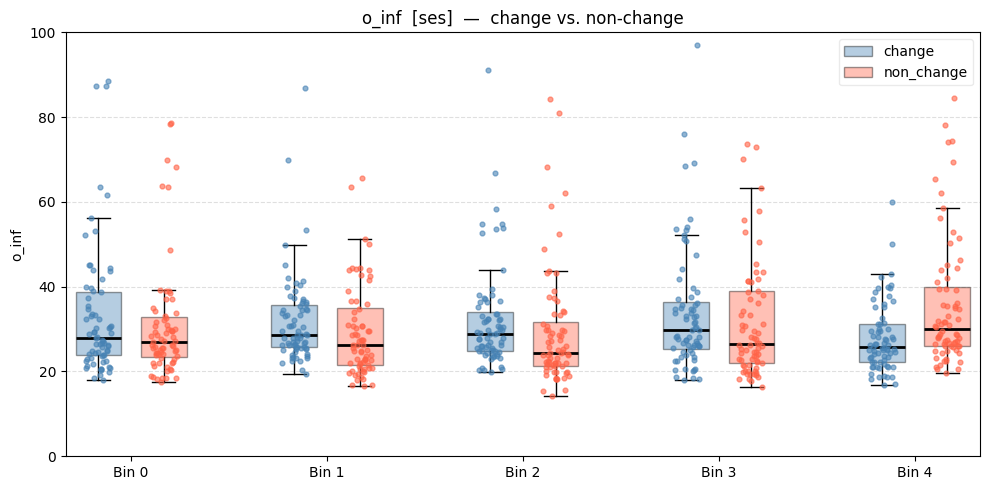

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_boxplots(results, metric, subset='ses', figsize=(10, 5)):
    bins = sorted(results['change'].keys())
    n    = len(bins)

    change_vals     = [results['change'][b][subset][metric]     for b in bins]
    non_change_vals = [results['non_change'][b][subset][metric] for b in bins]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_ylim(top=100)
    pos_c  = np.arange(n) * 3
    pos_nc = pos_c + 1

    kw = dict(widths=0.7, patch_artist=True,
              medianprops=dict(color='black', linewidth=2),
              showfliers=False)   # <-- outliers suppressed from box

    bp1 = ax.boxplot(change_vals,     positions=pos_c,
                     boxprops=dict(facecolor='steelblue', alpha=0.4), **kw)
    bp2 = ax.boxplot(non_change_vals, positions=pos_nc,
                     boxprops=dict(facecolor='tomato',    alpha=0.4), **kw)

    # jittered points on top
    rng = np.random.default_rng(0)
    for pos, vals, color in zip(pos_c,  change_vals,     ['steelblue'] * n):
        jitter = rng.uniform(-0.2, 0.2, len(vals))
        ax.scatter(pos + jitter, vals, color=color, alpha=0.6, s=12, zorder=3)

    for pos, vals, color in zip(pos_nc, non_change_vals, ['tomato'] * n):
        jitter = rng.uniform(-0.2, 0.2, len(vals))
        ax.scatter(pos + jitter, vals, color=color, alpha=0.6, s=12, zorder=3)

    ax.set_xticks(pos_c + 0.5)
    ax.set_xticklabels([f'Bin {b}' for b in bins])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}  [{subset}]  —  change vs. non-change')
    ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['change', 'non_change'],
              framealpha=0.4)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_metric_boxplots(results,metric="o_inf")